In [95]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions
helper_functions.set_plot_style()

In [96]:
SUBJECTS = helper_functions.fuglsang_get_subjects()

In [97]:
def load_trial_predictors(att_file, ign_file, predictor, padded, pred_dir = FUGLSANG_PRED_SELF_DIR):
    """
    Load trial predictors for a given predictor type.
    Handles both single and multivariate predictors.
    Returns att_pred, ign_pred as either NDVar or list of NDVar.
    """
    if isinstance(predictor, list):
        # multivariate — load each predictor separately and return as list
        att_preds = []
        ign_preds = []
        for p in predictor:
            p_name = helper_functions.get_predictor_name(p, padded)
            att_preds.append(eelbrain.load.unpickle(
                pred_dir / f'{att_file}~{p_name}.pickle'
            ))
            ign_preds.append(eelbrain.load.unpickle(
                pred_dir / f'{ign_file}~{p_name}.pickle'
            ))
        return att_preds, ign_preds
    else:
        # single predictor
        p_name = helper_functions.get_predictor_name(predictor, padded)
        att_pred = eelbrain.load.unpickle(
            pred_dir / f'{att_file}~{p_name}.pickle'
        )
        ign_pred = eelbrain.load.unpickle(
            pred_dir / f'{ign_file}~{p_name}.pickle'
        )
        return att_pred, ign_pred

In [98]:
def run_trial_aad(predictor, model_type, padded=False,
                  trf_dir=FUGLSANG_TRF_SELF_DIR,
                  pred_dir=FUGLSANG_PRED_SELF_DIR,
                  out_dir=FUGLSANG_AAD_RESULTS,
                  label='self'):
    """
    Run trial-level AAD for a given predictor and model type.
    Saves results to a CSV file, one row per trial.

    Parameters
    ----------
    predictor : PREDICTOR_TYPE or list of PREDICTOR_TYPE
        Predictor type(s) used for TRF estimation.
    model_type : MODEL_TYPE
        Forward or backward model.
    padded : bool
        Whether padded predictors were used.
    trf_dir : Path
        Directory containing subject-level TRF pickles.
    out_dir : Path
        Directory to save CSV results.

    Returns
    -------
    pd.DataFrame with one row per trial.
    """
    out_dir.mkdir(exist_ok=True, parents=True)

    suffix   = "_padded" if padded else ""
    p_name   = helper_functions.get_predictor_name(predictor, padded)

    att_trf_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, ATTENTION_TYPE.ATTENDED, model_type, GENERALISATION_TYPE.INDIVIDUAL, padded
    )
    ign_trf_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, predictor, ATTENTION_TYPE.IGNORED, model_type, GENERALISATION_TYPE.INDIVIDUAL, padded
    )

    csv_path = out_dir / f'trial_aad_{att_trf_name}_{label}.csv'
    if csv_path.exists():
        print(f"Results already exist at {csv_path}, loading.")
        return pd.read_csv(csv_path)

    rows = []

    for subject in SUBJECTS:

        # load TRFs
        att_trf_path = trf_dir / subject / f"{subject}_{att_trf_name}_trf.pickle"
        ign_trf_path = trf_dir / subject / f"{subject}_{ign_trf_name}_trf.pickle"

        if not att_trf_path.exists():
            print(f"{subject}: TRF not found at {att_trf_path}, skipping.")
            continue

        att_trf = eelbrain.load.unpickle(att_trf_path)
        ign_trf = eelbrain.load.unpickle(ign_trf_path)

        trials     = helper_functions.get_trials(subject)
        trials_dir = FUGLSANG_EEG_DIR / subject / f"trials{suffix}"

        for trial_idx, trial in trials.items():
            att_file = trial["attended"]
            ign_file = trial["ignored"]

            # load trial EEG
            eeg_path = trials_dir / f"trial_{trial_idx:02d}{suffix}.pickle"
            if not eeg_path.exists():
                print(f"{subject} trial {trial_idx}: EEG not found, skipping.")
                continue
            eeg_trial = eelbrain.load.unpickle(eeg_path)

            # load predictors — handles single and multivariate
            att_pred, ign_pred = load_trial_predictors(att_file, ign_file, predictor, padded, pred_dir=pred_dir)

            # duration from first predictor if list
            pred_for_duration = att_pred[0] if isinstance(att_pred, list) else att_pred
            duration_s = pred_for_duration.time.tmax

            if model_type == MODEL_TYPE.BACKWARD:
                correct, r_att, r_ign = helper_functions.aad_double_classifier(
                    eeg_trial, att_pred, ign_pred, att_trf, ign_trf
                )
            elif model_type == MODEL_TYPE.FORWARD:
                correct, r_att, r_ign = helper_functions.aad_double_classifier_forward(
                    att_pred, ign_pred, eeg_trial, att_trf, ign_trf
                )

            rows.append({
                'subject':       subject,
                'trial_idx':     trial_idx,
                'attended_file': att_file,
                'ignored_file':  ign_file,
                'duration_s':    duration_s,
                'r_att':         r_att,
                'r_ign':         r_ign,
                'correct':       correct,
                'predictor':     p_name,
                'model_type':    model_type.value,
                'padded':        padded,
            })

        print(f"{subject}: {sum(r['correct'] for r in rows if r['subject'] == subject)}"
              f"/{len(trials)} trials correct")

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved {len(df)} trial results to {csv_path}")

    return df

In [99]:
classifiers = [
    (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.FORWARD,  'Envelope\nForward'),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, MODEL_TYPE.FORWARD,  'Onset\nForward'),
    ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], MODEL_TYPE.FORWARD,  'Envelope+Onset\nForward'),
    (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
]

dfs = {}
for predictor, model_type, label in classifiers:
    df = run_trial_aad(predictor, model_type)
    dfs[label] = df

Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_self.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_onset_self.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope+envelope_onset_self.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_backward_attended_envelope_self.csv, loading.


In [100]:
def plot_trial_aad_summary(results_dir=FUGLSANG_AAD_RESULTS):
    """
    Bar plot of trial-level AAD classification accuracy for each model.
    Mirrors plot_aad_summary but using trial-level CSV results.
    """
    classifiers = [
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.FORWARD,  'Envelope\nForward'),
        (PREDICTOR_TYPE.ENVELOPE_ONSET, MODEL_TYPE.FORWARD,  'Onset\nForward'),
        ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], 
                                        MODEL_TYPE.FORWARD,  'Envelope+Onset\nForward'),
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
    ]

    rates    = []
    p_vals   = []
    correct_arrays = []  # for McNemar — bool array per model across all trials

    for predictor, model_type, _ in classifiers:
        att_trf_name = helper_functions.get_trf_model_name(
            DATASET_TYPE.FUGLSANG, predictor, ATTENTION_TYPE.ATTENDED, model_type, GENERALISATION_TYPE.INDIVIDUAL, False
        )
        csv_path = results_dir / f'trial_aad_{att_trf_name}_self.csv'
        df = pd.read_csv(csv_path)

        n_correct = df['correct'].sum()
        n_total   = len(df)

        binom   = helper_functions.binomial_test(n_correct, n_total)
        rates.append(n_correct / n_total)
        p_vals.append(binom['p'])
        correct_arrays.append(df['correct'].values)

    # McNemar comparisons
    comparisons = [
        (0, 3, 'Fwd vs Bwd'),
        (0, 1, 'Env vs Onset'),
    ]

    labels = [c[2] for c in classifiers]
    x      = np.arange(len(labels))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x, rates, color=colors, alpha=0.7, width=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', label='Chance (50%)')

    # binomial sig markers and accuracy labels
    for i, (rate, p) in enumerate(zip(rates, p_vals)):
        ax.text(i, rate + 0.01, helper_functions.sig_marker(p),
                ha='center', fontsize=12)
        ax.text(i, rate - 0.05, f"{rate*100:.1f}%",
                ha='center', fontsize=12)

    # McNemar sig lines
    for i, j, _ in comparisons:
        mc = helper_functions.mcnemar_test(correct_arrays[i], correct_arrays[j], exact=False) # use exact=False because we have enough trials for the chi-squared approximation to be valid
        y  = max(rates[i], rates[j]) + 0.06
        helper_functions.add_sig_line(
            ax, i, j, y,
            helper_functions.sig_marker(mc['p'])
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Classification Rate')
    ax.set_title('Trial-Level AAD Classification Summary')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FUGLSANG_FIGURES_DIR / 'fuglsang_trial_aad_summary.pdf', bbox_inches='tight')
    plt.show()

In [101]:
def plot_trial_aad_per_subject(results_dir=FUGLSANG_AAD_RESULTS):
    """
    Per-subject trial-level AAD accuracy for each model.
    Shows consistency of trial-level decoding across subjects.
    """
    classifiers = [
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.FORWARD,  'Envelope\nForward'),
        (PREDICTOR_TYPE.ENVELOPE_ONSET, MODEL_TYPE.FORWARD,  'Onset\nForward'),
        ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET],
                                        MODEL_TYPE.FORWARD,  'Envelope+Onset\nForward'),
        (PREDICTOR_TYPE.ENVELOPE,       MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
    ]

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    fig, axes = plt.subplots(1, len(classifiers),
                             figsize=(5 * len(classifiers), 6),
                             sharey=True)

    for ax, (predictor, model_type, label), color in zip(axes, classifiers, colors):

        att_trf_name = helper_functions.get_trf_model_name(
            DATASET_TYPE.FUGLSANG, predictor, ATTENTION_TYPE.ATTENDED, model_type, GENERALISATION_TYPE.INDIVIDUAL, False
        )
        csv_path = results_dir / f'trial_aad_{att_trf_name}_self.csv'
        df = pd.read_csv(csv_path)

        # per-subject accuracy
        subj_acc = (df.groupby('subject')['correct']
                      .agg(['sum', 'count'])
                      .assign(accuracy=lambda x: x['sum'] / x['count'])
                      .reset_index())

        # sort subjects for consistent ordering
        subj_acc = subj_acc.sort_values('subject')
        subjects = subj_acc['subject'].values
        accs     = subj_acc['accuracy'].values
        x        = np.arange(len(subjects))

        # bars per subject
        ax.bar(x, accs, color=color, alpha=0.7, width=0.6)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

        # mean line
        mean_acc = accs.mean()
        ax.axhline(mean_acc, color=color, linestyle='-',
                   linewidth=1.5, label=f'Mean: {mean_acc:.1%}')

        ax.set_xticks(x)
        ax.set_xticklabels(subjects, rotation=90, fontsize=8)
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Classification Rate (trials)')
    fig.suptitle('Trial-Level AAD Accuracy per Subject', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FUGLSANG_FIGURES_DIR / 'fuglsang_trial_aad_per_subject.pdf',
                bbox_inches='tight')
    plt.show()

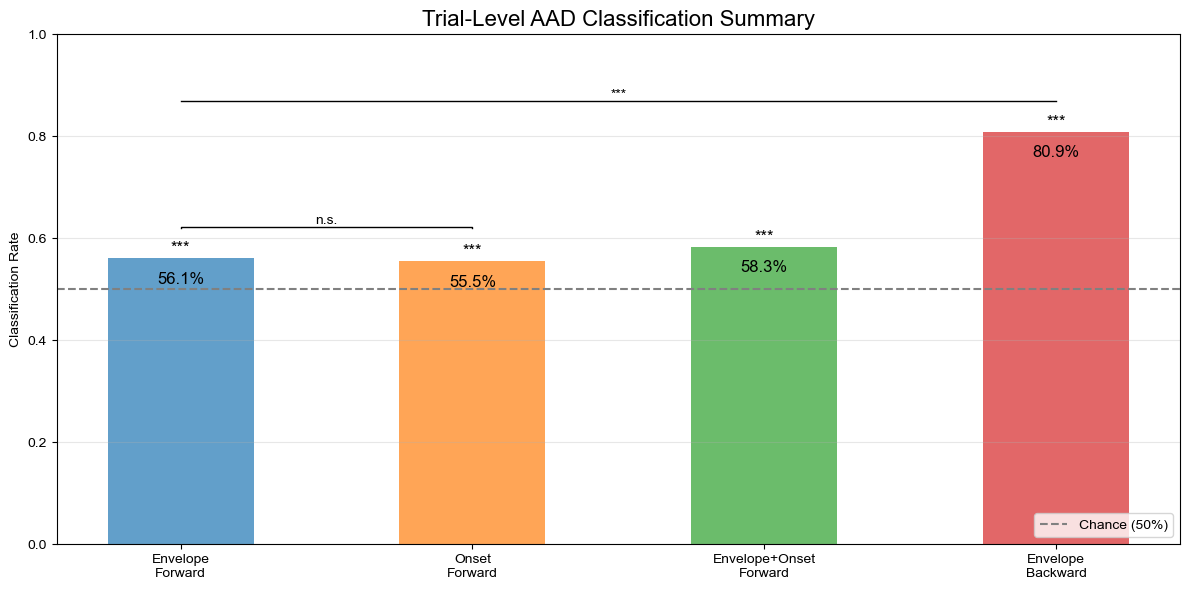

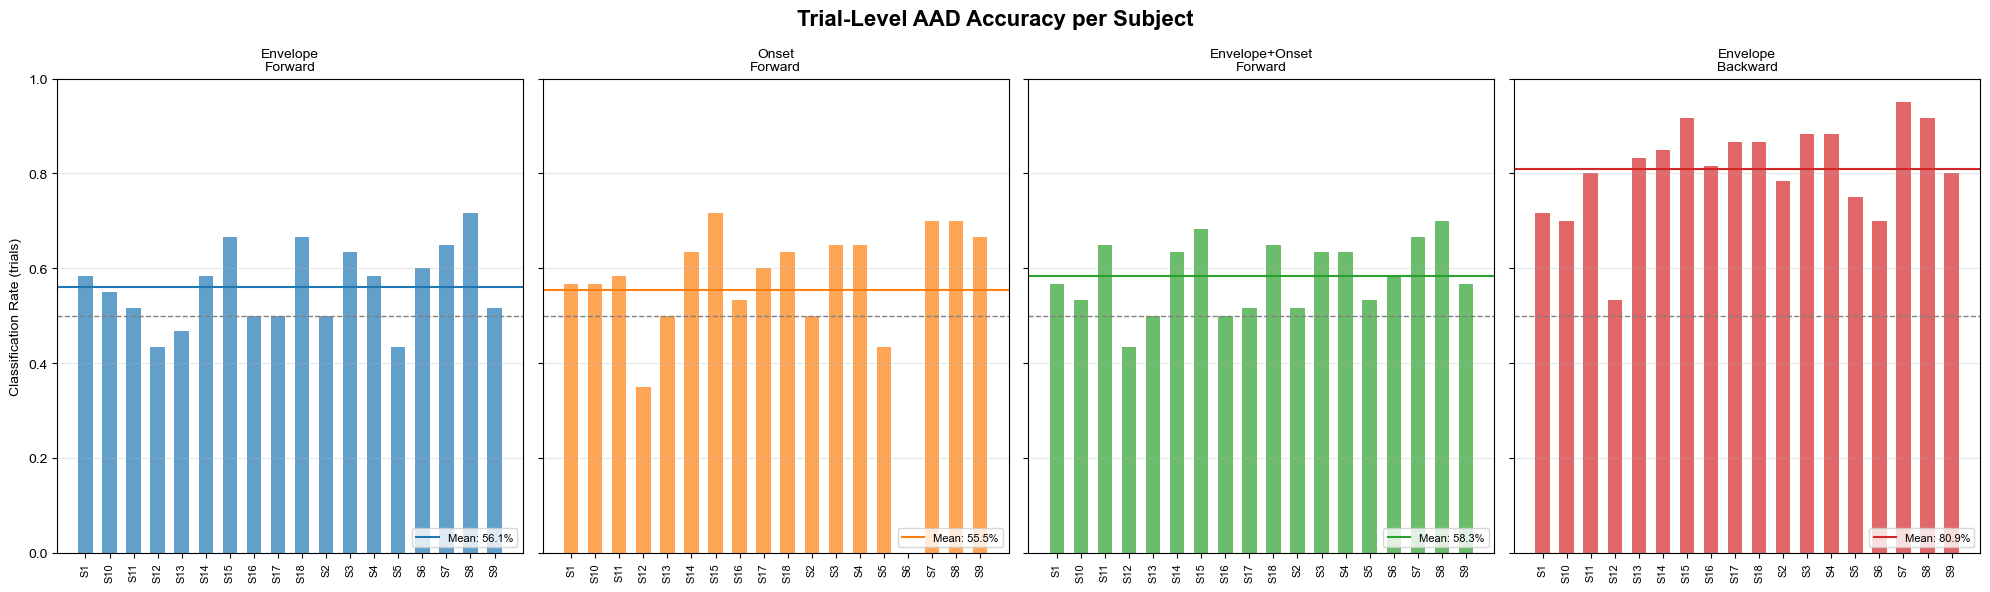

In [102]:
plot_trial_aad_summary()
plot_trial_aad_per_subject()

In [103]:
def plot_aad_summary_comparison():
    trf_dirs  = [FUGLSANG_TRF_MAT_DIR, FUGLSANG_TRF_SELF_DIR]
    pred_dirs = [FUGLSANG_PRED_MAT_DIR, FUGLSANG_PRED_SELF_DIR]
    trf_names = ["Imported", "Self computed"]

    classifiers = [
        (PREDICTOR_TYPE.ENVELOPE,                                    MODEL_TYPE.FORWARD,  'Envelope\nForward'),
        (PREDICTOR_TYPE.ENVELOPE_ONSET,                              MODEL_TYPE.FORWARD,  'Onset\nForward'),
        ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET],   MODEL_TYPE.FORWARD,  'Envelope+Onset\nForward'),
        (PREDICTOR_TYPE.ENVELOPE,                                    MODEL_TYPE.BACKWARD, 'Envelope\nBackward'),
    ]

    n_cls  = len(classifiers)
    n_dirs = len(trf_dirs)

    rates   = np.zeros((n_dirs, n_cls))
    p_vals  = np.zeros((n_dirs, n_cls))
    correct = [[None] * n_cls for _ in range(n_dirs)]  # bool arrays for McNemar

    pipeline_labels = ['imported', 'self']

    for d, (trf_dir, pred_dir, label) in enumerate(zip(trf_dirs, pred_dirs, pipeline_labels)):
        for c, (predictor, model_type, _) in enumerate(classifiers):
            df = run_trial_aad(predictor, model_type, trf_dir=trf_dir, pred_dir=pred_dir, label=label)

            corr_arr      = df['correct'].values.astype(bool)
            n_total       = len(corr_arr)
            n_correct     = corr_arr.sum()
            binom         = helper_functions.binomial_test(n_correct, n_total)

            rates[d, c]   = binom['accuracy']
            p_vals[d, c]  = binom['p']
            correct[d][c] = corr_arr

    # ── Grouped bar layout ────────────────────────────────────────────
    bar_width = 0.35
    gap       = 0.1
    group_w   = n_dirs * bar_width + gap
    x         = np.arange(n_cls) * group_w

    fig, ax = plt.subplots(figsize=(max(9, n_cls * group_w * 1.8), 5))

    clf_colors  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    dir_hatches = ['', '/////']

    for d in range(n_dirs):
        offsets = (d - (n_dirs - 1) / 2) * bar_width
        x_d     = x + offsets
        ax.bar(
            x_d, rates[d], width=bar_width,
            color=clf_colors[:n_cls], hatch=dir_hatches[d],
            alpha=0.7, label=trf_names[d]
        )
        for i, (rate, p) in enumerate(zip(rates[d], p_vals[d])):
            ax.text(x_d[i], rate + 0.01, helper_functions.sig_marker(p),
                    ha='center', fontsize=12)
            if d == 0:
                ax.text(x_d[i], rate - 0.05, f"{rate*100:.1f}%",
                    ha='center', fontsize=12)
            

        
        

    # ── Cross-dir McNemar lines ───────────────────────────────────────
    base_y = rates.max() + 0.06
    for c in range(n_cls):
        x_left  = x[c] - bar_width / 2
        x_right = x[c] + bar_width / 2
        res     = helper_functions.mcnemar_test(correct[0][c], correct[1][c], exact=False)
        helper_functions.add_sig_line(ax, x_left, x_right, base_y,
                                      helper_functions.sig_marker(res['p']))
        print(f"Comparison for {classifiers[c][2]}: McNemar p={res['p']:.4f}, ")

    # ── Legend ───────────────────────────────────────────────────────
    hatch_handles = [
        Patch(facecolor='white', edgecolor='black', hatch=dir_hatches[d], label=trf_names[d])
        for d in range(n_dirs)
    ]
    ax.legend(handles=hatch_handles, loc='lower right', ncol=2)

    ax.set_xticks(x)
    ax.set_xticklabels([c[2] for c in classifiers], fontsize=9)
    ax.set_ylabel('Classification Rate')
    ax.set_title('Trial-level AAD - pipeline comparison')
    ax.set_ylim(0.3, 1)
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1, label='Chance (50%)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FUGLSANG_FIGURES_DIR / 'fuglsang_aad_summary_comparison.pdf', bbox_inches='tight')
    plt.show()

Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_imported.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_onset_imported.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope+envelope_onset_imported.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_backward_attended_envelope_imported.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_self.csv, loading.
Results already exist at /Users/sylvestereley/Data/modelling-eeg-to-speech/fuglsang/aad-results/trial_aad_forward_attended_envelope_onset_self.csv, loading.
Results already exist at /Users/sylvestereley/Data

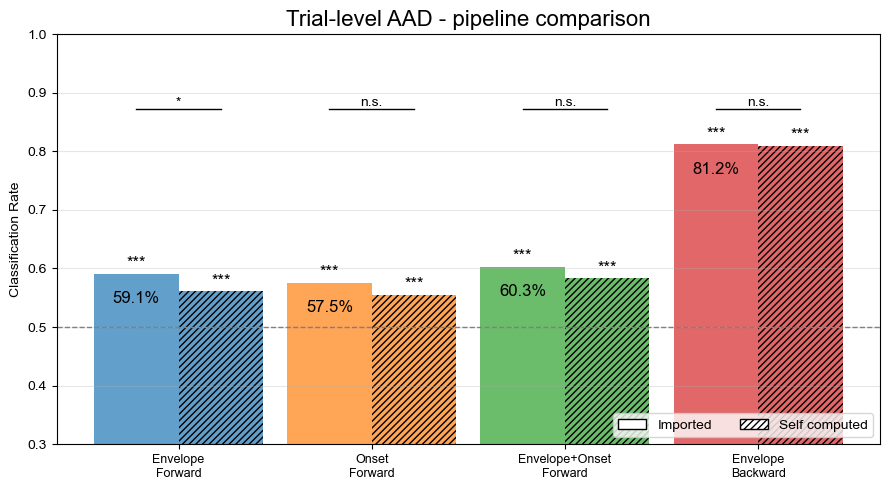

In [104]:
plot_aad_summary_comparison()